# Scenario & Sensitivity Analysis

Standalone planning analysis for the trained Victorian operational-demand forecasting model.

This notebook is designed to stay inside the repository's `notebooks/` folder. It reads the existing saved model and output dataset, recreates the original chronological test split, and writes scenario outputs only to `outputs/scenario_analysis/`.

It does not train a model or modify `main.py`, `src/`, tests, monitoring, tracking, or CI.

Scenarios:

1. Weather sensitivity: baseline, +2°C, +4°C
2. Demand growth: +5% applied to lag and rolling-demand features
3. Residential EV charging: +100 MW from 18:00 to 21:00


In [4]:
from pathlib import Path
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")


## 1. Locate the project and existing artifacts

The notebook works whether Jupyter starts in the repository root or inside `notebooks/`.


In [5]:
def find_project_root(start: Path) -> Path:
    """Find the repository root using files that already exist in this project."""
    start = start.resolve()

    for candidate in [start, *start.parents]:
        required = [
            candidate / "models" / "final_xgboost_model.json",
            candidate / "models" / "feature_columns.joblib",
            candidate / "outputs" / "training_dataset.csv",
        ]
        if all(path.exists() for path in required):
            return candidate

    raise FileNotFoundError(
        "Could not locate the project root. Keep this notebook inside the "
        "project's notebooks folder and ensure models/ and outputs/ exist."
    )


PROJECT_ROOT = find_project_root(Path.cwd())

MODEL_PATH = PROJECT_ROOT / "models" / "final_xgboost_model.json"
FEATURE_COLUMNS_PATH = PROJECT_ROOT / "models" / "feature_columns.joblib"
TRAINING_DATA_PATH = PROJECT_ROOT / "outputs" / "training_dataset.csv"

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "scenario_analysis"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TIMESTAMP_COLUMN = "INTERVAL_DATETIME"
TARGET_COLUMN = "OPERATIONAL_DEMAND"

TRAIN_RATIO = 0.70
VALIDATION_RATIO = 0.15

WEATHER_INCREASES_C = [0.0, 2.0, 4.0]
DEMAND_GROWTH_RATE = 0.05
EV_ADDITION_MW = 100.0
EV_START_HOUR = 18
EV_END_HOUR = 21

# Set dates such as "2026-03-01" and "2026-03-07" to shorten time-series plots.
PLOT_START = None
PLOT_END = None

print("Project root:", PROJECT_ROOT)
print("Model:", MODEL_PATH)
print("Features:", FEATURE_COLUMNS_PATH)
print("Dataset:", TRAINING_DATA_PATH)
print("Scenario outputs:", OUTPUT_DIR)


Project root: C:\Users\abeyt\Downloads\Energy Vic
Model: C:\Users\abeyt\Downloads\Energy Vic\models\final_xgboost_model.json
Features: C:\Users\abeyt\Downloads\Energy Vic\models\feature_columns.joblib
Dataset: C:\Users\abeyt\Downloads\Energy Vic\outputs\training_dataset.csv
Scenario outputs: C:\Users\abeyt\Downloads\Energy Vic\outputs\scenario_analysis


## 2. Load the existing model, saved features, and modelling dataset

In [6]:
model = XGBRegressor()
model.load_model(MODEL_PATH)

feature_columns = [
    str(column)
    for column in joblib.load(FEATURE_COLUMNS_PATH)
]

full_data = pd.read_csv(TRAINING_DATA_PATH)
full_data[TIMESTAMP_COLUMN] = pd.to_datetime(
    full_data[TIMESTAMP_COLUMN],
    errors="raise",
)
full_data = (
    full_data
    .sort_values(TIMESTAMP_COLUMN)
    .reset_index(drop=True)
)

required_columns = set(
    feature_columns + [TIMESTAMP_COLUMN, TARGET_COLUMN]
)
missing_columns = sorted(required_columns.difference(full_data.columns))

if missing_columns:
    raise ValueError(f"Dataset is missing required columns: {missing_columns}")

print("Model type:", type(model).__name__)
print("Dataset rows:", len(full_data))
print("Saved model features:", len(feature_columns))
print("Date range:", full_data[TIMESTAMP_COLUMN].min(), "to", full_data[TIMESTAMP_COLUMN].max())
print("Features:")
print(feature_columns)


Model type: XGBRegressor
Dataset rows: 17184
Saved model features: 34
Date range: 2025-06-08 04:30:00 to 2026-06-01 04:00:00
Features:
['year', 'month', 'day', 'day_of_week', 'hour', 'minute', 'is_weekend', 'lag_1', 'lag_2', 'lag_48', 'lag_336', 'rolling_mean_4', 'rolling_std_4', 'rolling_min_4', 'rolling_max_4', 'rolling_mean_48', 'rolling_std_48', 'rolling_min_48', 'rolling_max_48', 'time_of_day', 'time_sin', 'time_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos', 'temperature', 'relative_humidity', 'apparent_temperature', 'cloud_cover', 'wind_speed', 'solar_radiation', 'precipitation', 'is_raining']


## 3. Recreate the original chronological test set

The original pipeline used 70% training, 15% validation, and the final 15% for testing. Because the complete final modelling dataset was saved before splitting, the same test set can be recreated without rerunning the main pipeline.


In [7]:
total_rows = len(full_data)
train_end = int(total_rows * TRAIN_RATIO)
validation_end = train_end + int(total_rows * VALIDATION_RATIO)

test_data = full_data.iloc[validation_end:].copy().reset_index(drop=True)

print("Full dataset rows:", total_rows)
print("Recreated test rows:", len(test_data))
print("Test period:", test_data[TIMESTAMP_COLUMN].min(), "to", test_data[TIMESTAMP_COLUMN].max())

test_data[[TIMESTAMP_COLUMN, TARGET_COLUMN] + feature_columns].head()


Full dataset rows: 17184
Recreated test rows: 2579
Test period: 2026-04-08 11:00:00 to 2026-06-01 04:00:00


,INTERVAL_DATETIME,OPERATIONAL_DEMAND,year,month,day,day_of_week,hour,minute,is_weekend,lag_1,lag_2,lag_48,lag_336,rolling_mean_4,rolling_std_4,rolling_min_4,rolling_max_4,rolling_mean_48,rolling_std_48,rolling_min_48,rolling_max_48,time_of_day,time_sin,time_cos,day_of_week_sin,day_of_week_cos,month_sin,month_cos,temperature,relative_humidity,apparent_temperature,cloud_cover,wind_speed,solar_radiation,precipitation,is_raining
0,2026-04-08 11:00:00,4027,2026,4,8,2,11,0,0,"4,118.00","4,374.00","4,487.00","4,348.00","4,545.25",384.90,"4,118.00","5,008.00","5,026.73",607.04,"4,118.00","6,278.00",11.00,0.26,-0.97,0.97,-0.22,1.00,0.00,15.90,63.00,15.50,67.00,2.10,615.30,0.00,0
1,2026-04-08 11:30:00,3958,2026,4,8,2,11,30,0,"4,027.00","4,118.00","4,519.00","4,261.00","4,300.00",293.42,"4,027.00","4,681.00","5,017.15",619.25,"4,027.00","6,278.00",11.50,0.13,-0.99,0.97,-0.22,1.00,0.00,16.30,60.50,15.85,83.50,2.50,619.95,0.00,0
2,2026-04-08 12:00:00,3739,2026,4,8,2,12,0,0,"3,958.00","4,027.00","4,515.00","4,241.00","4,119.25",182.04,"3,958.00","4,374.00","5,005.46",633.97,"3,958.00","6,278.00",12.00,0.00,-1.00,0.97,-0.22,1.00,0.00,16.70,58.00,16.20,100.00,2.90,624.60,0.00,0
3,2026-04-08 12:30:00,3479,2026,4,8,2,12,30,0,"3,739.00","3,958.00","4,443.00","4,575.00","3,960.50",161.55,"3,739.00","4,118.00","4,989.29",656.25,"3,739.00","6,278.00",12.50,-0.13,-0.99,0.97,-0.22,1.00,0.00,16.95,56.50,16.30,100.00,2.45,570.35,0.00,0
4,2026-04-08 13:00:00,3338,2026,4,8,2,13,0,0,"3,479.00","3,739.00","4,337.00","4,894.00","3,800.75",247.15,"3,479.00","4,027.00","4,969.21",687.34,"3,479.00","6,278.00",13.00,-0.26,-0.97,0.97,-0.22,1.00,0.00,17.20,55.00,16.40,100.00,2.00,516.10,0.00,0


## 4. Helper functions

In [8]:
def predict(frame: pd.DataFrame) -> np.ndarray:
    return np.asarray(
        model.predict(frame[feature_columns]),
        dtype=float,
    )


def calculate_metrics(actual: pd.Series, predicted: np.ndarray) -> dict:
    actual_values = np.asarray(actual, dtype=float)
    predicted_values = np.asarray(predicted, dtype=float)

    errors = actual_values - predicted_values
    mae = np.mean(np.abs(errors))
    rmse = np.sqrt(np.mean(errors ** 2))

    non_zero = actual_values != 0
    mape = (
        np.mean(
            np.abs(
                (actual_values[non_zero] - predicted_values[non_zero])
                / actual_values[non_zero]
            )
        ) * 100
    )

    return {
        "MAE_MW": mae,
        "RMSE_MW": rmse,
        "MAPE_percent": mape,
        "Peak_MW": np.max(predicted_values),
        "Average_MW": np.mean(predicted_values),
    }


def select_plot_window(frame: pd.DataFrame) -> pd.DataFrame:
    selected = frame.copy()

    if PLOT_START is not None:
        selected = selected[selected[TIMESTAMP_COLUMN] >= pd.Timestamp(PLOT_START)]

    if PLOT_END is not None:
        selected = selected[selected[TIMESTAMP_COLUMN] <= pd.Timestamp(PLOT_END)]

    return selected


def save_current_figure(filename: str) -> None:
    plt.tight_layout()
    plt.savefig(
        OUTPUT_DIR / filename,
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()


## 5. Baseline forecast on the recreated test set

In [9]:
base_predictions = predict(test_data)

baseline_results = test_data[[TIMESTAMP_COLUMN, TARGET_COLUMN]].copy()
baseline_results["Base Forecast"] = base_predictions

baseline_metrics = pd.DataFrame(
    [calculate_metrics(test_data[TARGET_COLUMN], base_predictions)],
    index=["Base Forecast"],
)

baseline_metrics


,MAE_MW,RMSE_MW,MAPE_percent,Peak_MW,Average_MW
Base Forecast,61.04,86.85,1.17,"8,043.51","5,229.39"


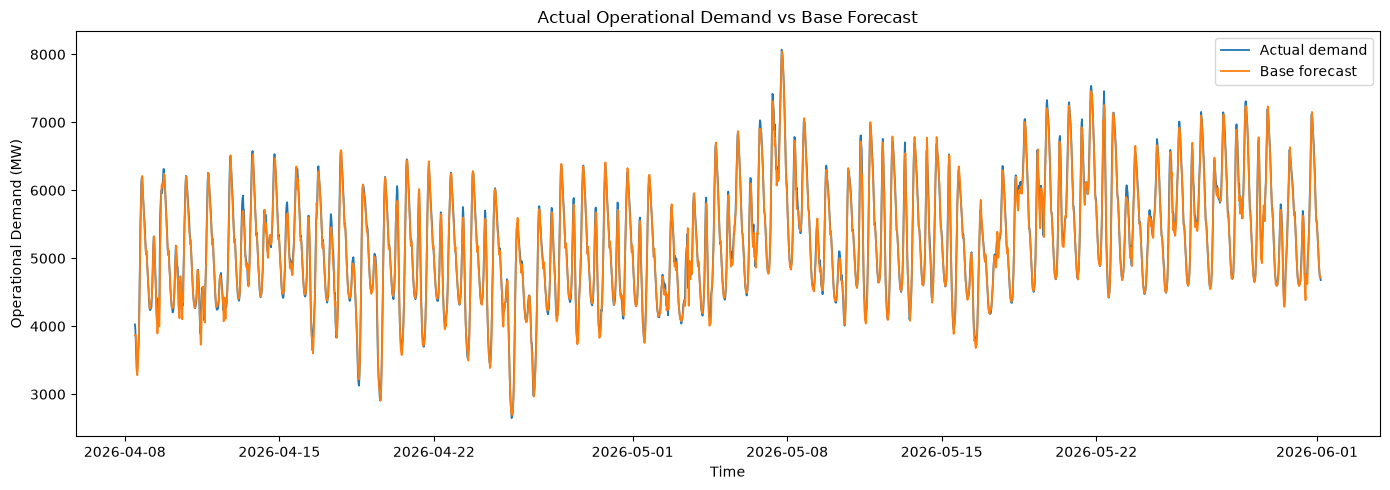

In [10]:
baseline_view = select_plot_window(baseline_results)

plt.figure(figsize=(14, 5))
plt.plot(
    baseline_view[TIMESTAMP_COLUMN],
    baseline_view[TARGET_COLUMN],
    label="Actual demand",
    linewidth=1.3,
)
plt.plot(
    baseline_view[TIMESTAMP_COLUMN],
    baseline_view["Base Forecast"],
    label="Base forecast",
    linewidth=1.3,
)
plt.title("Actual Operational Demand vs Base Forecast")
plt.xlabel("Time")
plt.ylabel("Operational Demand (MW)")
plt.legend()
save_current_figure("01_baseline_forecast.png")


## 6. Weather sensitivity analysis

Both `temperature` and `apparent_temperature` are shifted by the same amount. All other inputs remain unchanged, and the saved model is not retrained.


In [11]:
weather_features_to_shift = [
    column
    for column in ["temperature", "apparent_temperature"]
    if column in feature_columns
]

if "temperature" not in weather_features_to_shift:
    raise ValueError("The saved model does not contain the temperature feature.")

print("Weather features shifted:", weather_features_to_shift)


Weather features shifted: ['temperature', 'apparent_temperature']


In [12]:
weather_results = test_data[[TIMESTAMP_COLUMN, TARGET_COLUMN]].copy()
weather_summary_rows = []

for increase_c in WEATHER_INCREASES_C:
    scenario_data = test_data.copy()

    for column in weather_features_to_shift:
        scenario_data[column] = scenario_data[column] + increase_c

    scenario_predictions = predict(scenario_data)
    label = "Base Forecast" if increase_c == 0 else f"Temperature +{increase_c:.0f}°C"
    weather_results[label] = scenario_predictions

    metrics = calculate_metrics(test_data[TARGET_COLUMN], scenario_predictions)
    weather_summary_rows.append(
        {
            "Scenario": label,
            "Temperature_change_C": increase_c,
            **metrics,
            "Peak_change_vs_base_MW": np.max(scenario_predictions) - np.max(base_predictions),
            "Average_change_vs_base_MW": np.mean(scenario_predictions) - np.mean(base_predictions),
        }
    )

weather_summary = pd.DataFrame(weather_summary_rows).set_index("Scenario")
weather_summary


,Temperature_change_C,MAE_MW,RMSE_MW,MAPE_percent,Peak_MW,Average_MW,Peak_change_vs_base_MW,Average_change_vs_base_MW
Scenario,,,,,,,,
Base Forecast,0.00,61.04,86.85,1.17,"8,043.51","5,229.39",0.00,0.00
Temperature +2°C,2.00,63.35,89.17,1.21,"7,987.93","5,228.26",-55.58,-1.13
Temperature +4°C,4.00,65.53,91.71,1.25,"7,947.88","5,231.96",-95.63,2.56


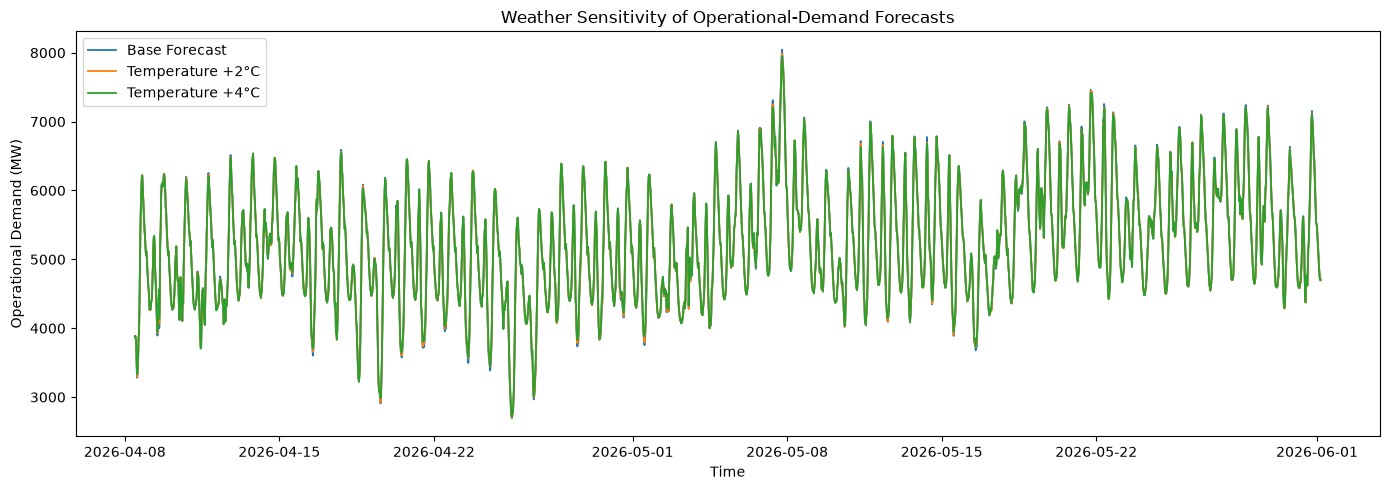

In [13]:
weather_view = select_plot_window(weather_results)

plt.figure(figsize=(14, 5))
for column in ["Base Forecast", "Temperature +2°C", "Temperature +4°C"]:
    plt.plot(
        weather_view[TIMESTAMP_COLUMN],
        weather_view[column],
        label=column,
        linewidth=1.3,
    )

plt.title("Weather Sensitivity of Operational-Demand Forecasts")
plt.xlabel("Time")
plt.ylabel("Operational Demand (MW)")
plt.legend()
save_current_figure("02_weather_sensitivity_timeseries.png")


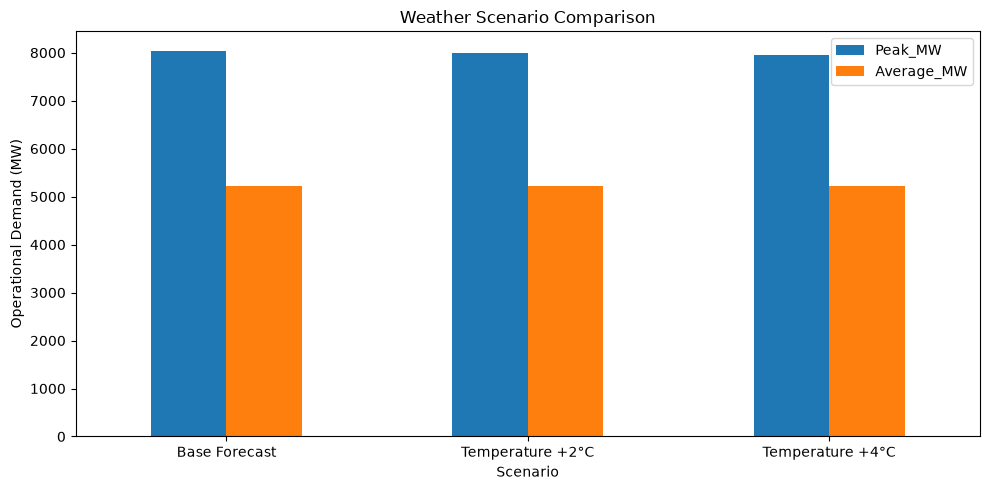

In [14]:
weather_summary[["Peak_MW", "Average_MW"]].plot(
    kind="bar",
    figsize=(10, 5),
)
plt.title("Weather Scenario Comparison")
plt.xlabel("Scenario")
plt.ylabel("Operational Demand (MW)")
plt.xticks(rotation=0)
save_current_figure("03_weather_sensitivity_summary.png")


## 7. Demand-growth scenario

The project's demand-history predictors are the `lag_*` and `rolling_*` features. These are increased by 5%, while calendar and weather features remain unchanged.


In [15]:
demand_history_features = [
    column
    for column in feature_columns
    if column.startswith("lag_") or column.startswith("rolling_")
]

if not demand_history_features:
    raise ValueError("No lag or rolling-demand features were found.")

print("Demand-history features increased by 5%:")
for column in demand_history_features:
    print(" -", column)


Demand-history features increased by 5%:
 - lag_1
 - lag_2
 - lag_48
 - lag_336
 - rolling_mean_4
 - rolling_std_4
 - rolling_min_4
 - rolling_max_4
 - rolling_mean_48
 - rolling_std_48
 - rolling_min_48
 - rolling_max_48


In [16]:
growth_data = test_data.copy()
growth_data[demand_history_features] = (
    growth_data[demand_history_features] * (1 + DEMAND_GROWTH_RATE)
)

growth_predictions = predict(growth_data)

growth_results = test_data[[TIMESTAMP_COLUMN, TARGET_COLUMN]].copy()
growth_results["Base Forecast"] = base_predictions
growth_results["Demand Growth +5%"] = growth_predictions

growth_summary = pd.DataFrame(
    [
        {
            "Scenario": "Base Forecast",
            **calculate_metrics(test_data[TARGET_COLUMN], base_predictions),
            "Peak_change_vs_base_MW": 0.0,
            "Average_change_vs_base_MW": 0.0,
        },
        {
            "Scenario": "Demand Growth +5%",
            **calculate_metrics(test_data[TARGET_COLUMN], growth_predictions),
            "Peak_change_vs_base_MW": np.max(growth_predictions) - np.max(base_predictions),
            "Average_change_vs_base_MW": np.mean(growth_predictions) - np.mean(base_predictions),
        },
    ]
).set_index("Scenario")

growth_summary


,MAE_MW,RMSE_MW,MAPE_percent,Peak_MW,Average_MW,Peak_change_vs_base_MW,Average_change_vs_base_MW
Scenario,,,,,,,
Base Forecast,61.04,86.85,1.17,"8,043.51","5,229.39",0.00,0.00
Demand Growth +5%,224.98,239.57,4.34,"8,311.50","5,478.60",267.99,249.21


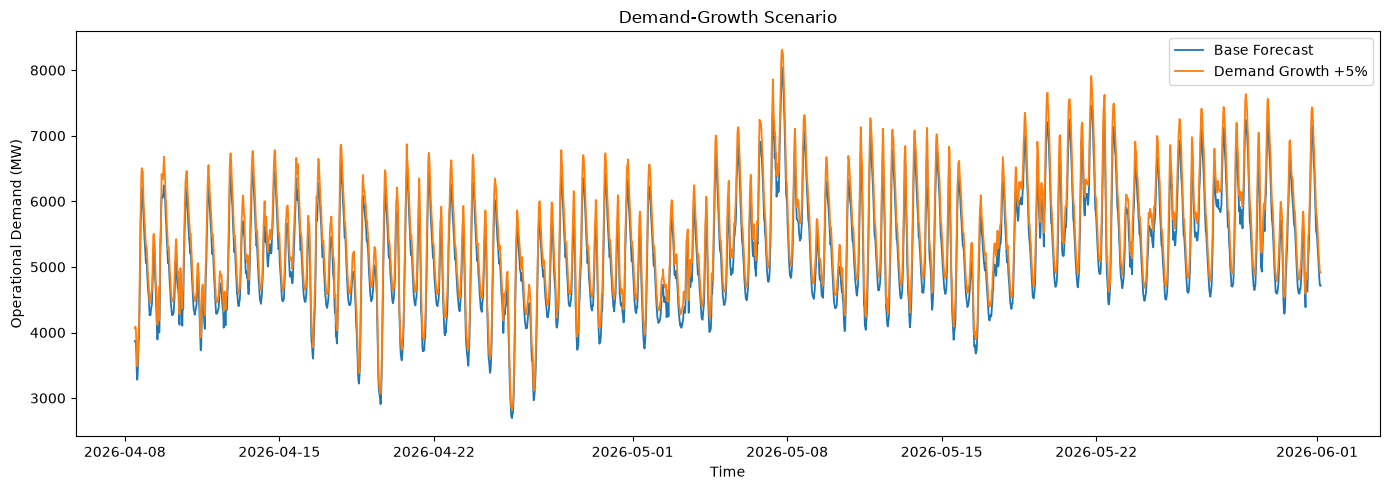

In [17]:
growth_view = select_plot_window(growth_results)

plt.figure(figsize=(14, 5))
plt.plot(
    growth_view[TIMESTAMP_COLUMN],
    growth_view["Base Forecast"],
    label="Base Forecast",
    linewidth=1.3,
)
plt.plot(
    growth_view[TIMESTAMP_COLUMN],
    growth_view["Demand Growth +5%"],
    label="Demand Growth +5%",
    linewidth=1.3,
)
plt.title("Demand-Growth Scenario")
plt.xlabel("Time")
plt.ylabel("Operational Demand (MW)")
plt.legend()
save_current_figure("04_demand_growth_timeseries.png")


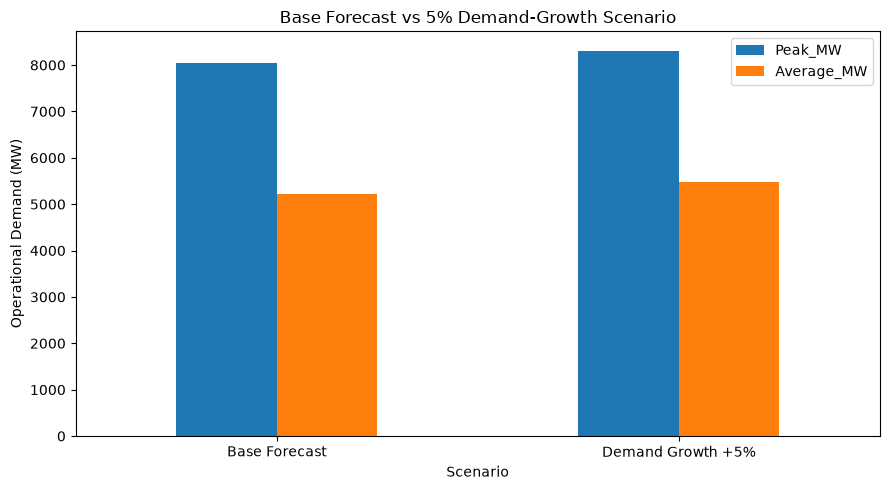

In [18]:
growth_summary[["Peak_MW", "Average_MW"]].plot(
    kind="bar",
    figsize=(9, 5),
)
plt.title("Base Forecast vs 5% Demand-Growth Scenario")
plt.xlabel("Scenario")
plt.ylabel("Operational Demand (MW)")
plt.xticks(rotation=0)
save_current_figure("05_demand_growth_summary.png")


## 8. Residential EV-charging scenario

This is a transparent planning overlay rather than a model-input sensitivity test. An additional 100 MW is added to the baseline forecast from 18:00 up to, but not including, 21:00.


In [19]:
ev_results = test_data[[TIMESTAMP_COLUMN, TARGET_COLUMN]].copy()
ev_results["Base Forecast"] = base_predictions

ev_window = (
    (ev_results[TIMESTAMP_COLUMN].dt.hour >= EV_START_HOUR)
    & (ev_results[TIMESTAMP_COLUMN].dt.hour < EV_END_HOUR)
)

ev_results["EV Charging Scenario"] = ev_results["Base Forecast"]
ev_results.loc[ev_window, "EV Charging Scenario"] += EV_ADDITION_MW

ev_predictions = ev_results["EV Charging Scenario"].to_numpy()

ev_summary = pd.DataFrame(
    [
        {
            "Scenario": "Base Forecast",
            **calculate_metrics(test_data[TARGET_COLUMN], base_predictions),
            "Peak_change_vs_base_MW": 0.0,
            "Average_change_vs_base_MW": 0.0,
            "Evening_average_change_MW": 0.0,
        },
        {
            "Scenario": "EV Charging Scenario",
            **calculate_metrics(test_data[TARGET_COLUMN], ev_predictions),
            "Peak_change_vs_base_MW": np.max(ev_predictions) - np.max(base_predictions),
            "Average_change_vs_base_MW": np.mean(ev_predictions) - np.mean(base_predictions),
            "Evening_average_change_MW": (
                ev_results.loc[ev_window, "EV Charging Scenario"].mean()
                - ev_results.loc[ev_window, "Base Forecast"].mean()
            ),
        },
    ]
).set_index("Scenario")

ev_summary


,MAE_MW,RMSE_MW,MAPE_percent,Peak_MW,Average_MW,Peak_change_vs_base_MW,Average_change_vs_base_MW,Evening_average_change_MW
Scenario,,,,,,,,
Base Forecast,61.04,86.85,1.17,"8,043.51","5,229.39",0.00,0.00,0.00
EV Charging Scenario,64.92,90.54,1.24,"8,143.51","5,241.96",100.00,12.56,100.00


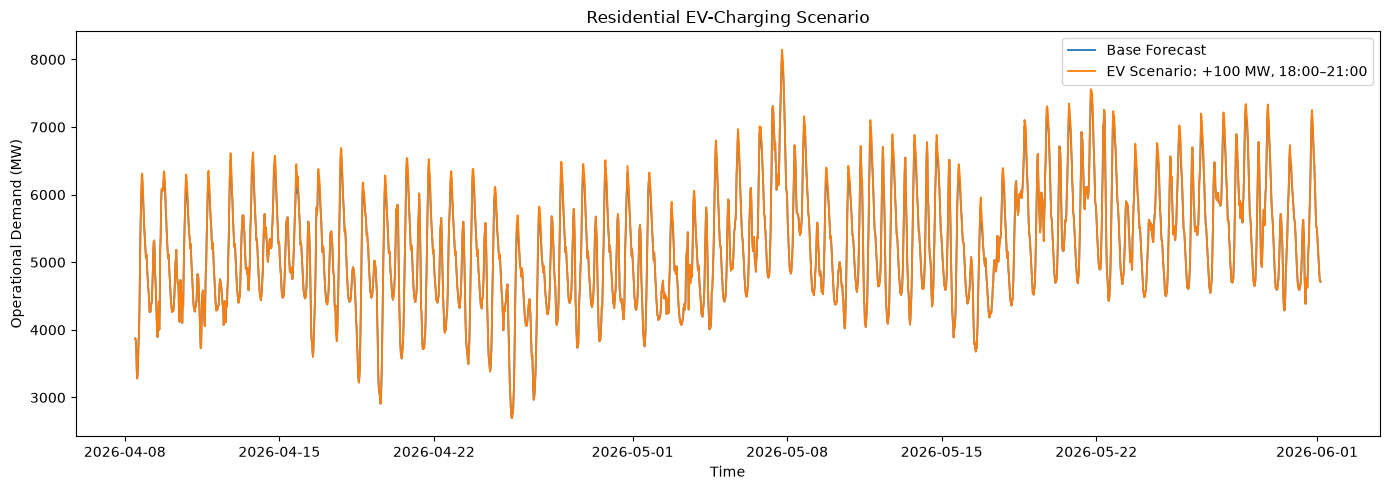

In [20]:
ev_view = select_plot_window(ev_results)

plt.figure(figsize=(14, 5))
plt.plot(
    ev_view[TIMESTAMP_COLUMN],
    ev_view["Base Forecast"],
    label="Base Forecast",
    linewidth=1.3,
)
plt.plot(
    ev_view[TIMESTAMP_COLUMN],
    ev_view["EV Charging Scenario"],
    label=f"EV Scenario: +{EV_ADDITION_MW:.0f} MW, 18:00–21:00",
    linewidth=1.3,
)
plt.title("Residential EV-Charging Scenario")
plt.xlabel("Time")
plt.ylabel("Operational Demand (MW)")
plt.legend()
save_current_figure("06_ev_charging_timeseries.png")


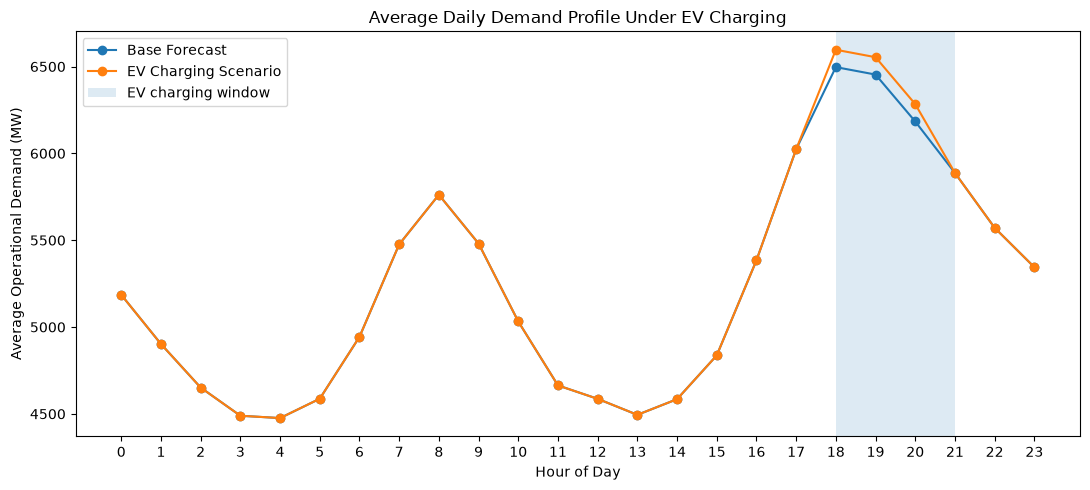

In [21]:
hourly_ev_profile = (
    ev_results
    .assign(hour=ev_results[TIMESTAMP_COLUMN].dt.hour)
    .groupby("hour")[["Base Forecast", "EV Charging Scenario"]]
    .mean()
)

hourly_ev_profile.plot(figsize=(11, 5), marker="o")
plt.axvspan(
    EV_START_HOUR,
    EV_END_HOUR,
    alpha=0.15,
    label="EV charging window",
)
plt.title("Average Daily Demand Profile Under EV Charging")
plt.xlabel("Hour of Day")
plt.ylabel("Average Operational Demand (MW)")
plt.xticks(range(24))
plt.legend()
save_current_figure("07_ev_charging_daily_profile.png")


## 9. Combined scenario summary

In [22]:
combined_summary = pd.DataFrame(
    [
        {
            "Scenario": "Weather +2°C",
            "Assumption": "Temperature and apparent temperature increased by 2°C",
            "Peak_demand_MW": weather_summary.loc["Temperature +2°C", "Peak_MW"],
            "Peak_change_vs_base_MW": weather_summary.loc["Temperature +2°C", "Peak_change_vs_base_MW"],
            "Average_change_vs_base_MW": weather_summary.loc["Temperature +2°C", "Average_change_vs_base_MW"],
        },
        {
            "Scenario": "Weather +4°C",
            "Assumption": "Temperature and apparent temperature increased by 4°C",
            "Peak_demand_MW": weather_summary.loc["Temperature +4°C", "Peak_MW"],
            "Peak_change_vs_base_MW": weather_summary.loc["Temperature +4°C", "Peak_change_vs_base_MW"],
            "Average_change_vs_base_MW": weather_summary.loc["Temperature +4°C", "Average_change_vs_base_MW"],
        },
        {
            "Scenario": "Demand Growth +5%",
            "Assumption": "All lag and rolling-demand features increased by 5%",
            "Peak_demand_MW": growth_summary.loc["Demand Growth +5%", "Peak_MW"],
            "Peak_change_vs_base_MW": growth_summary.loc["Demand Growth +5%", "Peak_change_vs_base_MW"],
            "Average_change_vs_base_MW": growth_summary.loc["Demand Growth +5%", "Average_change_vs_base_MW"],
        },
        {
            "Scenario": "EV Charging",
            "Assumption": f"+{EV_ADDITION_MW:.0f} MW from 18:00 to 21:00",
            "Peak_demand_MW": ev_summary.loc["EV Charging Scenario", "Peak_MW"],
            "Peak_change_vs_base_MW": ev_summary.loc["EV Charging Scenario", "Peak_change_vs_base_MW"],
            "Average_change_vs_base_MW": ev_summary.loc["EV Charging Scenario", "Average_change_vs_base_MW"],
        },
    ]
)

combined_summary


,Scenario,Assumption,Peak_demand_MW,Peak_change_vs_base_MW,Average_change_vs_base_MW
0,Weather +2°C,Temperature and apparent temperature increased...,"7,987.93",-55.58,-1.13
1,Weather +4°C,Temperature and apparent temperature increased...,"7,947.88",-95.63,2.56
2,Demand Growth +5%,All lag and rolling-demand features increased ...,"8,311.50",267.99,249.21
3,EV Charging,+100 MW from 18:00 to 21:00,"8,143.51",100.00,12.56


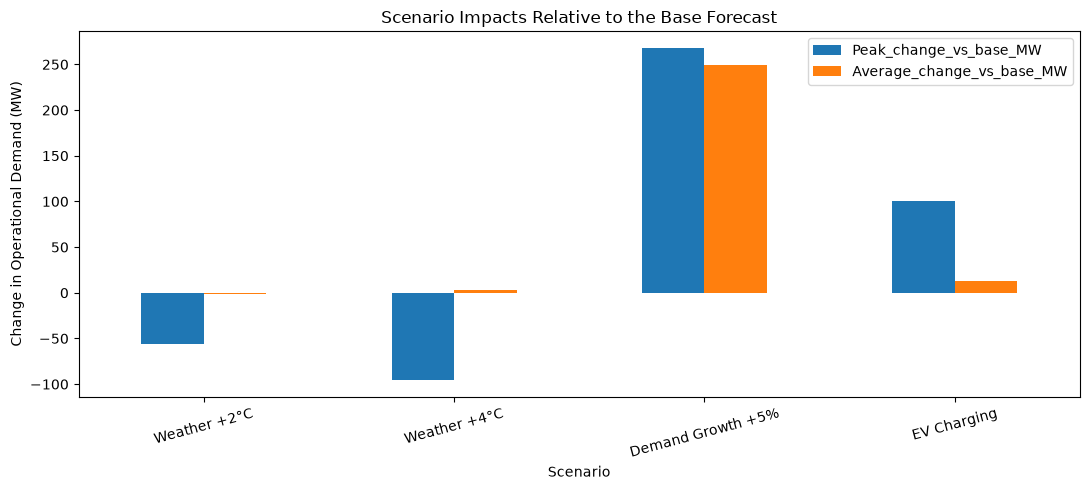

In [23]:
combined_summary.set_index("Scenario")[[
    "Peak_change_vs_base_MW",
    "Average_change_vs_base_MW",
]].plot(kind="bar", figsize=(11, 5))

plt.title("Scenario Impacts Relative to the Base Forecast")
plt.xlabel("Scenario")
plt.ylabel("Change in Operational Demand (MW)")
plt.xticks(rotation=15)
save_current_figure("08_combined_scenario_impacts.png")


## 10. Save scenario results

In [24]:
baseline_results.to_csv(
    OUTPUT_DIR / "baseline_predictions.csv",
    index=False,
)
weather_results.to_csv(
    OUTPUT_DIR / "weather_scenario_predictions.csv",
    index=False,
)
growth_results.to_csv(
    OUTPUT_DIR / "demand_growth_predictions.csv",
    index=False,
)
ev_results.to_csv(
    OUTPUT_DIR / "ev_charging_predictions.csv",
    index=False,
)
combined_summary.to_csv(
    OUTPUT_DIR / "scenario_summary.csv",
    index=False,
)

print("Saved scenario tables and figures to:")
print(OUTPUT_DIR)


Saved scenario tables and figures to:
C:\Users\abeyt\Downloads\Energy Vic\outputs\scenario_analysis


## 11. Interpretation

**Weather sensitivity:** The temperature scenarios assess how the existing forecast responds to warmer conditions while holding non-temperature inputs constant.

**Demand growth:** Increasing historical-demand features provides a simple planning sensitivity for higher underlying consumption.

**EV charging:** The evening overlay illustrates how residential electrification could increase the evening demand profile and potentially affect system peaks.

